# Stock prices

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import requests
from datetime import datetime, timedelta

## Playing around with the Massive API 

### First Call with a `TICKER`, a `START_DATE` and an `END_DATE`

In [2]:
API_KEY = "lw74z4qgzk7li5OWTgPj6XFG36Z_Yqj3"

In [5]:
TICKER = "AAPL"
START_DATE = "2026-01-01"
END_DATE = "2026-05-31"
url=f"https://api.massive.com/v2/aggs/ticker/{TICKER}/range/1/day/{START_DATE}/{END_DATE}?adjusted=true&sort=asc&limit=120&apiKey={API_KEY}"
url

'https://api.massive.com/v2/aggs/ticker/AAPL/range/1/day/2026-01-01/2026-05-31?adjusted=true&sort=asc&limit=120&apiKey=lw74z4qgzk7li5OWTgPj6XFG36Z_Yqj3'

In [6]:
response = requests.get(url)
response.ok

True

In [8]:
results = response.json()
results.keys()

dict_keys(['ticker', 'queryCount', 'resultsCount', 'adjusted', 'results', 'status', 'request_id', 'count'])

In [11]:
len(results["results"])

102

In [38]:
pd.DataFrame(results["results"]).head()

,v,vw,o,c,h,l,t,n
0,37838054.0,271.9197,272.255,271.01,277.84,269.00,1767330000000,642187
1,45647190.0,267.9755,270.640,267.26,271.51,266.14,1767589200000,754339
2,52352090.0,263.1381,267.000,262.36,267.55,262.12,1767675600000,783173
3,48309804.0,261.4392,263.200,260.33,263.68,259.81,1767762000000,732706
4,50419337.0,257.4496,257.020,259.04,259.29,255.70,1767848400000,764090


In [20]:
tmp0 = results["results"][0]
tmp0

{'v': 37838054.0,
 'vw': 271.9197,
 'o': 272.255,
 'c': 271.01,
 'h': 277.84,
 'l': 269,
 't': 1767330000000,
 'n': 642187}

In [21]:
tmp0["t"]

1767330000000

In [24]:
datetime.fromtimestamp(tmp0["t"]/1000.0)

datetime.datetime(2026, 1, 2, 13, 0)

In [25]:
tmp1 = results["results"][1]
datetime.fromtimestamp(tmp1["t"]/1000.0)

datetime.datetime(2026, 1, 5, 13, 0)

In [26]:
tmp2 = results["results"][2]
datetime.fromtimestamp(tmp2["t"]/1000.0)

datetime.datetime(2026, 1, 6, 13, 0)

In [27]:
tmp3 = results["results"][3]
datetime.fromtimestamp(tmp3["t"]/1000.0)

datetime.datetime(2026, 1, 7, 13, 0)

In [29]:
for idx,result in enumerate(results["results"]):
    if idx < 20:
        tmp = results["results"][idx]
        print(datetime.fromtimestamp(tmp["t"]/1000.0))
    if idx >=20:
        break

2026-01-02 13:00:00
2026-01-05 13:00:00
2026-01-06 13:00:00
2026-01-07 13:00:00
2026-01-08 13:00:00
2026-01-09 13:00:00
2026-01-12 13:00:00
2026-01-13 13:00:00
2026-01-14 13:00:00
2026-01-15 13:00:00
2026-01-16 13:00:00
2026-01-20 13:00:00
2026-01-21 13:00:00
2026-01-22 13:00:00
2026-01-23 13:00:00
2026-01-26 13:00:00
2026-01-27 13:00:00
2026-01-28 13:00:00
2026-01-29 13:00:00
2026-01-30 13:00:00


### Second Call with a `TICKER`, an `END_DATE` and the `LAST_DAYS`

#### Fix datetime

In [42]:
def fix_datetime_on_dataframe(df):
    df['date'] = pd.to_datetime(df['t'], origin='unix', unit='ms')
    return df.set_index(keys='date').drop(columns='t')

#### Fix Column Names

In [43]:
def fix_column_names_on_dataframe(df):
    mapping = {
        'o': 'open',
        'c': 'close',
        'h': 'high',
        'l': 'low',
        'n': 'number',
        'v': 'volume',
        'vw': 'avg_price'
    }
    return df.rename(columns=mapping)

#### Automating the request through a Python Function

In [44]:
end_date = datetime.today() - timedelta(days=1)
end_date

datetime.datetime(2026, 6, 9, 12, 12, 7, 946064)

In [45]:
datetime.strftime(end_date, "%Y-%m-%d")

'2026-06-09'

In [46]:
def create_stock_df_of_company(company_code):

    ### Company's code

    company_code = company_code.upper()

    ### Last 90 days

    start_date = datetime.today() - timedelta(days=91)
    end_date = datetime.today() - timedelta(days=1)
    start = datetime.strftime(start_date, "%Y-%m-%d")
    end = datetime.strftime(end_date, "%Y-%m-%d")

    ### URL and Requests

    url = f"https://api.massive.com/v2/aggs/ticker/{company_code}/range/1/day/{start}/{end}?apiKey={API_KEY}"

    api_data = requests.get(url).json()

    df = pd.DataFrame(api_data['results'])
    df = fix_datetime_on_dataframe(df)
    df = fix_column_names_on_dataframe(df)
    df['company_code'] = company_code
    return df

#### Trying the function with the `AAPL` stock price

In [47]:
apple_df = create_stock_df_of_company('AAPL')
apple_df.head()

,volume,avg_price,open,close,high,low,number,company_code
date,,,,,,,,
2026-03-11 04:00:00,2.621893e+07,260.6671,261.090,260.81,262.130,259.55,493478,AAPL
2026-03-12 04:00:00,4.079402e+07,255.7310,258.660,255.76,258.950,254.18,664408,AAPL
2026-03-13 04:00:00,3.692999e+07,251.8400,255.480,250.12,256.330,249.52,664343,AAPL
2026-03-16 04:00:00,3.207421e+07,252.7539,252.105,252.82,253.885,249.88,614630,AAPL
2026-03-17 04:00:00,3.236161e+07,254.1579,252.955,254.23,255.130,252.18,482574,AAPL


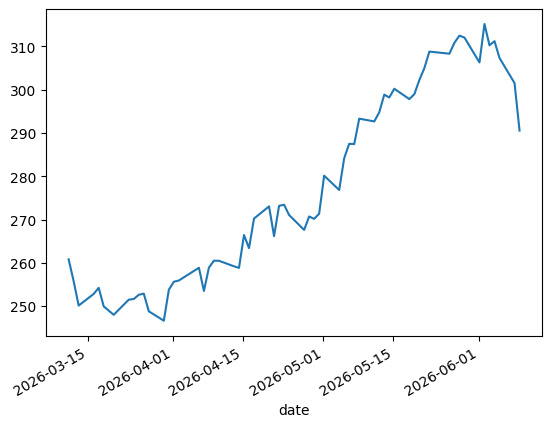

In [48]:
apple_df['close'].plot(kind='line');

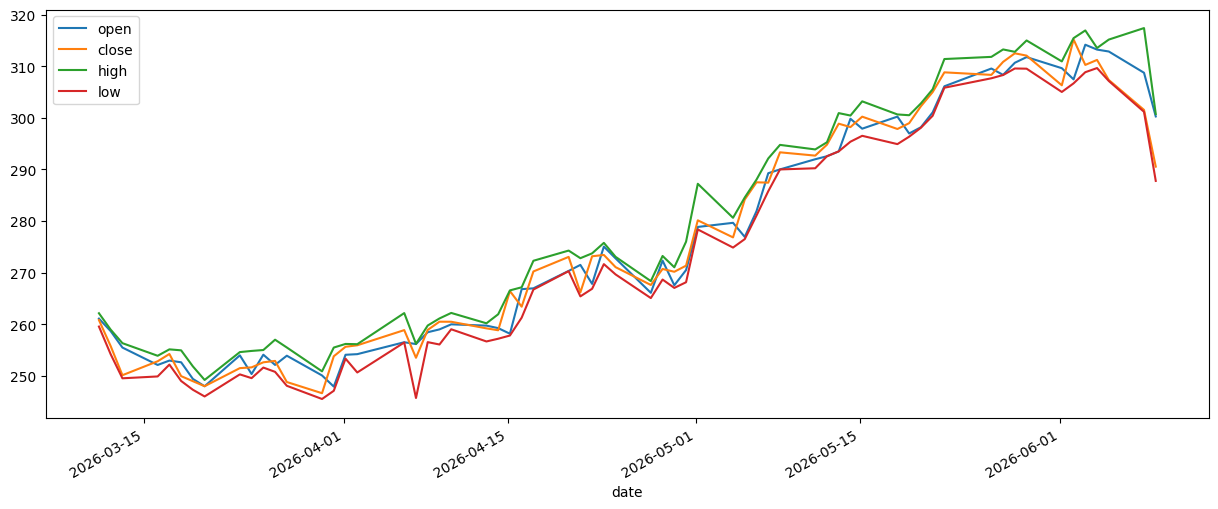

In [49]:
apple_df[['open', 'close', 'high', 'low']].plot(kind='line', figsize=(15,6));

##### Test your code

In [50]:
from nbresult import ChallengeResult

result = ChallengeResult('apple',
    index_name=apple_df.index.name,
    index_type=apple_df.index.dtype,
    columns=apple_df.columns
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
Fugue tests will be initialized with options:
rootdir: /Users/davywai/code/lewagon/slb-ds-2026/Module02_DataToolkit/02-DataSourcingPandas/01-Stock-Market-API/tests
plugins: fugue-0.9.1, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_apple.py::TestApple::test_apple_df_columns PASSED                   [ 33%]
test_apple.py::TestApple::test_apple_df_index_is_timestamp PASSED        [ 66%]
test_apple.py::TestApple::test_apple_df_index_name_is_date PASSED        [100%]

============================== 3 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/apple.pickle

git commit -m 'Completed apple step'

git push origin master



In [52]:
# Set default figsize for all notebook (usefull in TS analysis)
matplotlib.rcParams['figure.figsize'] = (15, 6)

#### Trying the function with more companies (`GOOGL`, `META`)

In [53]:
codes = ['AMZN', 'GOOGL', 'META']
stock_dfs = [apple_df]
for code in codes:
    stock_dfs.append(create_stock_df_of_company(code))

In [54]:
stocks_df = pd.concat(stock_dfs)
stocks_df.head()

,volume,avg_price,open,close,high,low,number,company_code
date,,,,,,,,
2026-03-11 04:00:00,2.621893e+07,260.6671,261.090,260.81,262.130,259.55,493478,AAPL
2026-03-12 04:00:00,4.079402e+07,255.7310,258.660,255.76,258.950,254.18,664408,AAPL
2026-03-13 04:00:00,3.692999e+07,251.8400,255.480,250.12,256.330,249.52,664343,AAPL
2026-03-16 04:00:00,3.207421e+07,252.7539,252.105,252.82,253.885,249.88,614630,AAPL
2026-03-17 04:00:00,3.236161e+07,254.1579,252.955,254.23,255.130,252.18,482574,AAPL


<Axes: xlabel='date'>

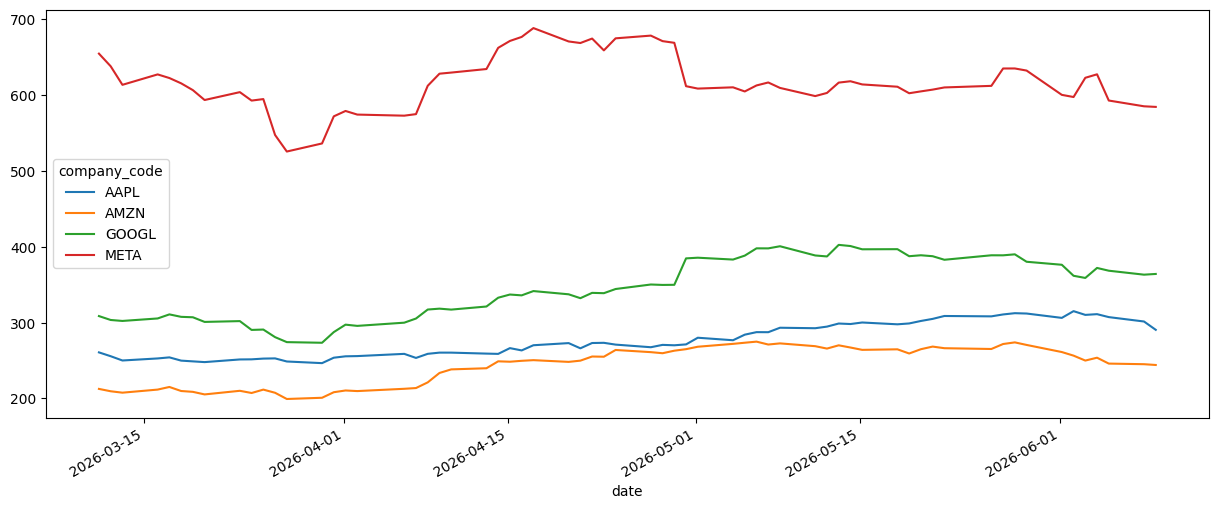

In [55]:
# Pivot the table to get company_code as columns
pivot_df = stocks_df.pivot(columns='company_code', values='close')
pivot_df.plot(kind='line')

In [56]:
def normalize(series):
    return series / series[0]

normalized_pivot = pivot_df.apply(normalize, axis=0)

/var/folders/6p/s5dyg_x13_zbgfd_xsyg3s7c0000gn/T/ipykernel_2280/1697112155.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return series / series[0]


<Axes: xlabel='date'>

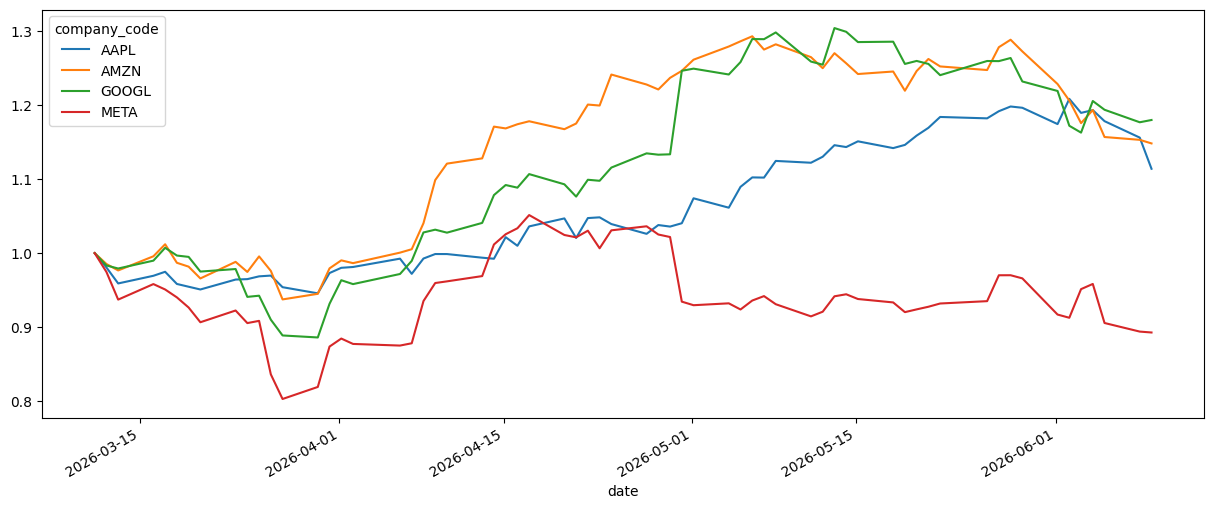

In [57]:
normalized_pivot.plot(kind='line')